 # 1. Estructura Tabular (Pandas):

En esta primera fase, necesitamos un DataFrame para cargar y manipular los archivos True.csv y Fake.csv. Dado que estamos trabajando en un entorno objetivo de CPU, aplicaremos un muestreo balanceado para mantener baja la complejidad computacional.

Los pasos que realiza el siguiente código son:

* Carga de datos: Lectura de los archivos base.

* Construcción de etiquetas: Asignación de la clase 1 a las noticias verdaderas (True.csv) y la clase 0 a las noticias falsas (Fake.csv).


* Muestreo: Selección de un subconjunto equitativo de ambas clases.


* Unificación: Combinación de las columnas title y text para consolidar el contenido que será vectorizado posteriormente.

In [6]:
import pandas as pd
import sys
from google.colab import drive

# 2. Cargar los archivos base
# IMPORTANTE: Revisa si "Redes Neuronales Graficas (GNN) - Inteligencia Artificial"
# es exactamente el nombre de tu carpeta principal en Drive.
ruta_true = '/content/DatosTrue.csv'
ruta_fake = '/content/DatosFake.csv'

# Intentamos cargar los archivos especificando la codificación latin1
try:
    df_true = pd.read_csv(ruta_true, encoding='latin1')
    df_fake = pd.read_csv(ruta_fake, encoding='latin1')
    print("✅ Archivos cargados correctamente.\n")
except FileNotFoundError:
    print("⚠️ Error: No se encontraron los archivos.")
    print(f"Por favor, verifica que la ruta sea exactamente: {ruta_true}")
    # Detenemos la ejecución de esta celda para evitar el NameError
    sys.exit("Deteniendo ejecución por falta de archivos.")
except Exception as e:
    print(f"⚠️ Ocurrió un error inesperado: {e}\n")
    sys.exit("Deteniendo ejecución por error inesperado.")

# 3. Construcción de etiquetas (1 para True, 0 para Fake)
df_true['label'] = 1
df_fake['label'] = 0

# 4. Muestreo balanceado
n_muestras = 1000

# Usamos random_state para que la ejecución sea reproducible
df_true_sampled = df_true.sample(n=n_muestras, random_state=42)
df_fake_sampled = df_fake.sample(n=n_muestras, random_state=42)

# 5. Combinar y mezclar el dataset final
df_balanceado = pd.concat([df_true_sampled, df_fake_sampled], ignore_index=True)
df_balanceado = df_balanceado.sample(frac=1, random_state=42).reset_index(drop=True)

# 6. Unir 'title' y 'text' en una sola columna 'content' para mayor contexto
df_balanceado['content'] = df_balanceado['title'].fillna('') + " " + df_balanceado['text'].fillna('')

# Verificar los resultados
print(f"Dataset balanceado creado con éxito.")
print(f"Total de muestras: {len(df_balanceado)}")
print("\nDistribución de clases:")
print(df_balanceado['label'].value_counts())




✅ Archivos cargados correctamente.

Dataset balanceado creado con éxito.
Total de muestras: 2000

Distribución de clases:
label
0    1000
1    1000
Name: count, dtype: int64


In [10]:
import pandas as pd

# 1. Define la ruta exacta de tu archivo en Google Drive
# (Este es el ejemplo para las noticias verdaderas, puedes cambiar 'True.csv' por 'Fake.csv')
ruta_archivo = '/content/DatosTrue.csv'

# 2. Carga el archivo CSV en un DataFrame
# Recuerda mantener el encoding='latin1' para evitar errores de lectura
df_datos = pd.read_csv(ruta_archivo, encoding='latin1')

# 3. Visualiza los datos de forma interactiva y ordenada
# display() genera una tabla mucho más visual en Colab que un simple print()
display(df_datos.head())

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


# 2. Matriz de Características (TF-IDF)
En esta etapa, transformaremos el texto limpio de nuestras noticias en datos comprensibles para la red neuronal.

Representaremos el texto inicial utilizando una matriz TF-IDF. Cada fila de esta matriz se convertirá en un nodo dentro de nuestro futuro grafo, y las columnas representarán la importancia (el peso) de palabras específicas en cada noticia individual.

Además, en este paso convertiremos las matrices resultantes directamente a Tensores de PyTorch (x para las características e y para las etiquetas), que es el formato nativo que requiere PyTorch Geometric.

In [16]:
from sklearn.feature_extraction.text import TfidfVectorizer
import torch
import pandas as pd
from IPython.display import display

# 1. Configurar el vectorizador TF-IDF
# Limitamos a 3000 características (palabras más frecuentes) para no sobrecargar la CPU en este entorno.
# También aplicamos stop_words='english' para limpiar palabras comunes sin significado profundo.
vectorizer = TfidfVectorizer(max_features=3000, stop_words='english')

# 2. Aplicar la vectorización a la columna 'content' que creamos en el paso anterior
print("Vectorizando el texto... Esto puede tomar unos segundos.")
X_tfidf = vectorizer.fit_transform(df_balanceado['content']).toarray()

# 3. Convertir a tensores de PyTorch (Nodos 'x' y Etiquetas 'y')
# 'x' será nuestra matriz de características y 'y' nuestras etiquetas de clase (1 o 0)
x_tensor = torch.tensor(X_tfidf, dtype=torch.float)
y_tensor = torch.tensor(df_balanceado['label'].values, dtype=torch.long)

print(f"✅ Vectorización completada y tensores creados.")
print(f"Forma del tensor de características (x_tensor): {x_tensor.shape} -> ({x_tensor.shape[0]} nodos, {x_tensor.shape[1]} atributos)")
print(f"Forma del tensor de etiquetas (y_tensor): {y_tensor.shape}")

# ---------------------------------------------------------
# 4. VISUALIZADOR: Muestra de la matriz matemática
# ---------------------------------------------------------
# Obtenemos los nombres de las palabras procesadas para los encabezados
nombres_features = vectorizer.get_feature_names_out()

# Creamos un DataFrame solo para visualizar cómo se ve por dentro la matriz para las primeras 5 noticias y 15 palabras
df_visualizacion = pd.DataFrame(X_tfidf[:10, :15], columns=nombres_features[:15])

print("\n🔍 VISUALIZADOR TF-IDF:")
print("Así se ven las primeras 5 noticias transformadas en números según el peso de las 15 primeras palabras del vocabulario:")
display(df_visualizacion)

Vectorizando el texto... Esto puede tomar unos segundos.
✅ Vectorización completada y tensores creados.
Forma del tensor de características (x_tensor): torch.Size([2000, 3000]) -> (2000 nodos, 3000 atributos)
Forma del tensor de etiquetas (y_tensor): torch.Size([2000])

🔍 VISUALIZADOR TF-IDF:
Así se ven las primeras 5 noticias transformadas en números según el peso de las 15 primeras palabras del vocabulario:


,000,00pm,10,100,11,12,13,14,15,150,16,17,18,19,20
0,0.000000,0.0,0.000000,0.0,0.030167,0.030101,0.000000,0.000000,0.029113,0.0,0.0,0.0,0.000000,0.0,0.02754
1,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.00000
2,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.030418,0.000000,0.0,0.0,0.0,0.000000,0.0,0.00000
3,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.00000
4,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.00000
5,0.080287,0.0,0.088092,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.00000
6,0.000000,0.0,0.000000,0.0,0.000000,0.036473,0.038122,0.000000,0.000000,0.0,0.0,0.0,0.040716,0.0,0.00000
7,0.000000,0.0,0.305823,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.00000
8,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.00000
9,0.010985,0.0,0.000000,0.0,0.000000,0.000000,0.014546,0.015632,0.000000,0.0,0.0,0.0,0.000000,0.0,0.00000


# 3. Estructura de Grafo (PyTorch Geometric Data)

Esta es la estructura núcleo de nuestro proyecto. PyTorch Geometric (PyG) requiere que empaquetemos toda nuestra información en un objeto Data que consolide nodos, aristas y etiquetas.

Para lograrlo, realizaremos lo siguiente:

1.   Nodos (x) y Etiquetas (y): Utilizaremos los tensores que ya generamos en el paso anterior.

2.   Aristas (edge_index): Calcularemos la similitud coseno entre todas las noticias vectorizadas. Luego, aplicaremos el algoritmo de los k vecinos más cercanos (k-NN) para conectar cada noticia con las $k$ noticias más parecidas a ella. Esto creará la "red" por donde fluirá la información en nuestro modelo GraphSAGE.

In [18]:
!pip install torch_geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 996.4 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 8.1 MB/s eta 0:00:00


In [19]:
import numpy as np
import torch
from sklearn.metrics.pairwise import cosine_similarity
from torch_geometric.data import Data

# 1. Definir el número de vecinos (k-NN)
# Conectaremos cada noticia con las 5 noticias más similares a ella
k_vecinos = 5

# 2. Calcular la matriz de similitud coseno
print("Calculando similitud coseno entre las noticias (esto puede tomar un momento)...")
# X_tfidf proviene de la celda anterior
sim_matrix = cosine_similarity(X_tfidf)

edges_source = []
edges_target = []

# 3. Construir las conexiones (Aristas/Edges)
print(f"Construyendo la topología del grafo usando k-NN (k={k_vecinos})...")
for i in range(len(df_balanceado)):
    # Obtenemos los índices de las noticias con mayor similitud
    # np.argsort ordena de menor a mayor. Tomamos los 'k' últimos.
    # Restamos 1 para excluir la propia noticia 'i' (similitud consigo misma es 1.0)
    vecinos_idx = np.argsort(sim_matrix[i])[-k_vecinos-1:-1]

    for vecino in vecinos_idx:
        edges_source.append(i) # Nodo de origen
        edges_target.append(vecino) # Nodo de destino

# 4. Convertir a tensor de PyTorch Geometric
# PyG requiere que edge_index tenga la forma [2, num_aristas] y sea de tipo long
edge_index = torch.tensor([edges_source, edges_target], dtype=torch.long)

# 5. EMPAQUETADO FINAL: Crear el objeto Data de PyG
grafo_data = Data(x=x_tensor, edge_index=edge_index, y=y_tensor)

# 6. Visualización de los resultados
print("\n✅ Estructura de Grafo 'SentinelGrafo' creada exitosamente.")
print("-" * 50)
print("Resumen del objeto Data:")
print(f"🔹 Número total de Nodos (Noticias): {grafo_data.num_nodes}")
print(f"🔹 Número total de Aristas (Conexiones): {grafo_data.num_edges}")
print(f"🔹 Características por Nodo (Dimensión TF-IDF): {grafo_data.num_node_features}")
print(f"🔹 Número de Clases a predecir: 2 (True=1, Fake=0)")
print("-" * 50)

Calculando similitud coseno entre las noticias (esto puede tomar un momento)...
Construyendo la topología del grafo usando k-NN (k=5)...

✅ Estructura de Grafo 'SentinelGrafo' creada exitosamente.
--------------------------------------------------
Resumen del objeto Data:
🔹 Número total de Nodos (Noticias): 2000
🔹 Número total de Aristas (Conexiones): 10000
🔹 Características por Nodo (Dimensión TF-IDF): 3000
🔹 Número de Clases a predecir: 2 (True=1, Fake=0)
--------------------------------------------------


# 4. Visualización de la Topología del Grafo
Antes de proceder al entrenamiento, vamos a visualizar una porción de nuestro SentinelGrafo. Utilizaremos la librería NetworkX para dibujar la red.

Para mantener la gráfica legible, visualizaremos un subconjunto de nodos. Asignaremos colores para distinguir las clases:

- 🟢 Verde: Noticias Reales (True)

- 🔴 Rojo: Noticias Falsas (Fake)

Si el algoritmo de similitud textual funcionó bien, deberíamos empezar a ver comunidades o grupos de nodos del mismo color conectados entre sí.

Preparando la visualización del grafo...


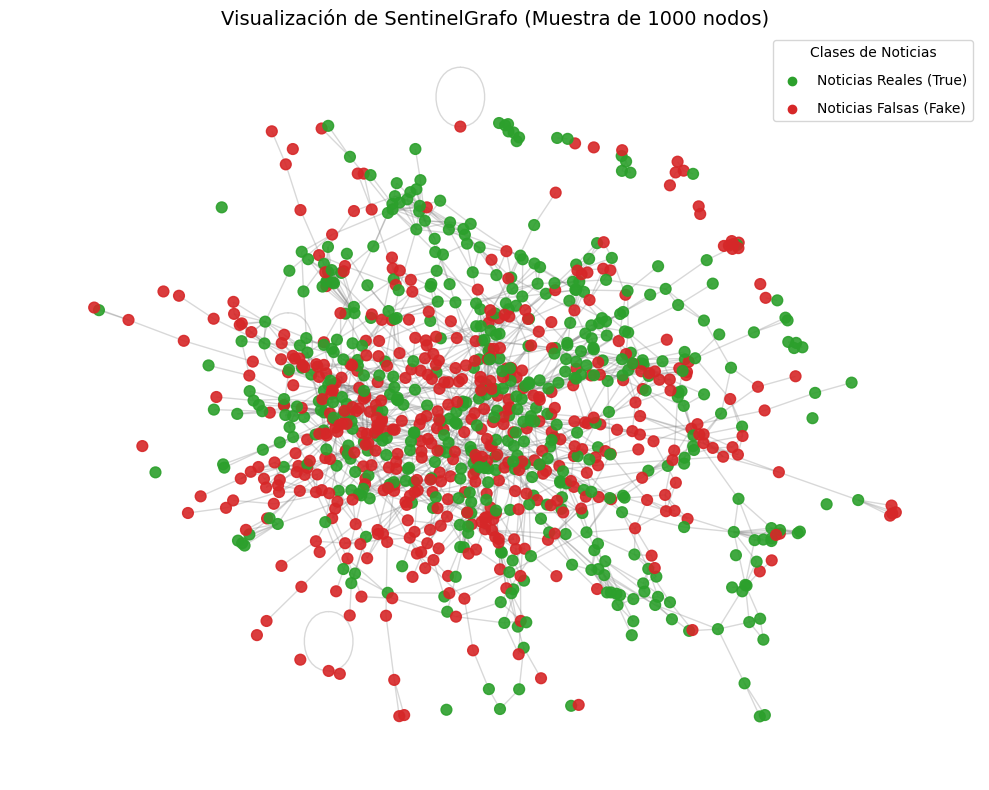

In [24]:
import networkx as nx
import matplotlib.pyplot as plt
from torch_geometric.utils import to_networkx
import torch

print("Preparando la visualización del grafo...")

# 1. Definir el tamaño de la muestra a visualizar (ej. 100 nodos)
nodos_a_mostrar = 1000

# Filtrar las aristas para que solo queden las conexiones entre los primeros 100 nodos
mascara = (edge_index[0] < nodos_a_mostrar) & (edge_index[1] < nodos_a_mostrar)
sub_edge_index = edge_index[:, mascara]

# 2. Crear un objeto Data temporal más pequeño solo para la gráfica
sub_data = Data(
    x=x_tensor[:nodos_a_mostrar],
    edge_index=sub_edge_index,
    y=y_tensor[:nodos_a_mostrar]
)

# 3. Convertir de PyTorch Geometric a NetworkX
# to_undirected=True hace que las líneas no tengan flechas para una vista más limpia
G = to_networkx(sub_data, to_undirected=True)

# 4. Asignar colores basados en las etiquetas reales (y)
# 1 (True) -> Verde, 0 (Fake) -> Rojo
colores_nodos = ['#2ca02c' if etiqueta == 1 else '#d62728' for etiqueta in sub_data.y.numpy()]

# 5. Dibujar el Grafo con Matplotlib
plt.figure(figsize=(10, 8))

# spring_layout usa un algoritmo de física para separar los nodos estéticamente
pos = nx.spring_layout(G, seed=42, k=0.15)

nx.draw_networkx_nodes(G, pos, node_color=colores_nodos, node_size=60, alpha=0.9)
nx.draw_networkx_edges(G, pos, alpha=0.3, edge_color='gray')

# Crear una leyenda personalizada
plt.scatter([], [], c='#2ca02c', label='Noticias Reales (True)')
plt.scatter([], [], c='#d62728', label='Noticias Falsas (Fake)')
plt.legend(scatterpoints=1, frameon=True, labelspacing=1, title="Clases de Noticias")

plt.title(f"Visualización de SentinelGrafo (Muestra de {nodos_a_mostrar} nodos)", fontsize=14)
plt.axis('off') # Ocultar los ejes cartesianos
plt.tight_layout()
plt.show()